# Corr_3PCF: Standard and Multipole Three-Point Statistics

This notebook covers two closely related topics:

- the reduced 3PCF `Q` measured from triangle configurations in real space
- a saved multipole representation of the same angular information

## Core idea

PyHermes builds three field factors associated with a triangle, estimates their triplet product over many rotations and centers, and then forms the reduced statistic `Q = zeta / zeta_H`. The choice of center sampling leads to the two main estimator styles used below: particle centers and box-random centers.


In [1]:
from pyhermes.theory.corr3pcf import Corr_3PCF
from pyhermes.param.parambase import read_param
from pyhermes.utils.sampling import random_points_box
from pyhermes.io import WindowFunc, ConvolsData, Corr3PCFData, Corr3PCFMultipoleData
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. Standard 3PCF workflows

The standard task is controlled by the triangle side lengths, the angular sampling, the number of random rotations, the center strategy, and the smoothing windows applied to the triangle legs.


### Command-line entry point

The first two runs use the standard driver script with two different center choices: particle centers and random box centers.


In [2]:
! mpirun -np 4 python ./scripts/run_3pcf.py ./configs/param_3pcf_pcenter_nrot20.yaml

18:45:22 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_3pcf_pcenter_nrot20.yaml'
18:45:22 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
18:45:22 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
18:45:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
18:45:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.random' from 'None' to 'uniform'
18:45:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window.type' from 'empty' to 'sphere'
18:45:22 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window.len_args.R'
18:45:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.n_rot' from '100' to '20'
18:45:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.center' from 'box_random' to 'particle

In [3]:
! mpirun -np 4 python ./scripts/run_3pcf.py ./configs/param_3pcf_rcenter_nrot20.yaml

18:47:26 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_3pcf_rcenter_nrot20.yaml'
18:47:26 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
18:47:26 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
18:47:26 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
18:47:26 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.random' from 'None' to 'uniform'
18:47:26 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window2.type' from 'empty' to 'sphere'
18:47:26 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window2.len_args.R'
18:47:26 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window3.type' from 'empty' to 'sphere'
18:47:26 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.wind

### Compare particle-center and box-random-center saved outputs

The next cell reloads both results and compares their reduced 3PCF curves directly. This is the fastest way to see how the estimator choice changes the measured `Q(theta)`.


18:49:22 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl <---
18:49:22 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
18:49:22 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
18:49:22 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['ddd', 'rrr', 'd_delta_dd', 'r_delta_dd', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']
18:49:22 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_rcenter_nrot20.pkl <---
18:49:22 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
18:49:22 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
18:49:22 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['rrr', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']


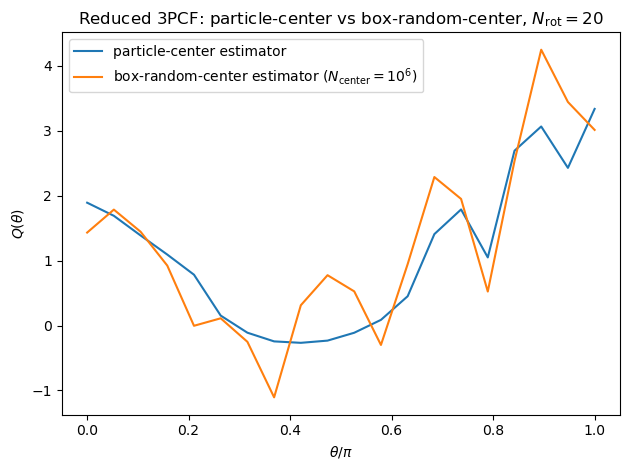

In [4]:
corr3pcf_pcent = Corr3PCFData(data_path='./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl')
corr3pcf_rcent = Corr3PCFData(data_path='./output/quijote8000_snap004_3pcf_rcenter_nrot20.pkl')
plt.plot(corr3pcf_pcent.theta/np.pi, corr3pcf_pcent.Q, label='particle-center estimator')
plt.plot(corr3pcf_rcent.theta/np.pi, corr3pcf_rcent.Q, label=r'box-random-center estimator ($N_{\rm center}=10^6$)')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.legend()
plt.title(r'Reduced 3PCF: particle-center vs box-random-center, $N_{\rm rot}=20$')
plt.tight_layout()
plt.show()


### Config-driven Python API

This version keeps the YAML config in charge but returns the result directly to the notebook, which is useful for quick parameter scans.


In [5]:
corr3pcf_params = read_param('./configs/param_3pcf_pcenter_nrot20.yaml')
task = Corr_3PCF(param_task=corr3pcf_params)
task.threads = 8
task.products = 'Q'
corr3pcf = task.run(save_result=False)

18:49:22 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_3pcf_pcenter_nrot20.yaml'
18:49:22 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
18:49:22 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
18:49:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
18:49:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.random' from 'None' to 'uniform'
18:49:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.window.type' from 'empty' to 'sphere'
18:49:22 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_3PCF.window.len_args.R'
18:49:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.n_rot' from '100' to '20'
18:49:22 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_3PCF.center' from 'box_random' to 'particle

### Task object overrides

These cells show a mixed-object workflow in which data fields, random fields, and windows can be supplied either as loaded objects or as paths. This is often the most practical level for custom experiments.


In [6]:
D = ConvolsData(data_path='./output/quijote8000_snap004_sfc.pkl', threads=8)
random = ConvolsData(data_path='./output/random_sfc.pkl', threads=8)
win_params_sph5 = {"type": "sphere", "len_args": {"R": 5}}
filter_sph5 = WindowFunc(win_params_sph5, D.convols_info, threads=8)

18:49:55 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
18:49:55 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
18:49:55 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/random_sfc.pkl <---
18:49:55 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -2.192e-07, Max = 9.48e-07, Mean = 5.96e-08, Sum = 1


In [7]:
task = Corr_3PCF()
task.convols_data1 = D
task.convols_data2 = "./output/quijote8000_snap004_sfc.pkl"
task.convols_data3 = "./output/quijote8000_snap004_sfc.pkl"
task.random1 = "uniform"
task.random2 = "./output/random_sfc.pkl"
task.random3 = random
task.window2 = win_params_sph5
task.window3 = filter_sph5
task.r12 = 20.0
task.r23 = 40.0
task.n_theta = 20
task.n_rot = 20
task.center = "particle"
# task.particle_pos1 = D.get_particle_data()['pos']
# task.random_pos1 = random_points_box(count=1000000, box_size=1000, seed=42)
task.products = "Q"
task.threads = 8
corr3pcf1 = task.run(save_result=False)

18:49:55 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...

18:49:55 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - Corr_3PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
18:49:55 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - Preparing Corr_3PCF input fields ...
18:49:55 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - center=particle, r12=20.0, r13=40.0, n_rot=20, base_seed=42, threads=8
18:49:55 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - angle_param=theta, theta_min=0.0, theta_max=3.141592653589793, n_theta=20
18:49:55 - INFO - pyhermes.pipeline.pipeline:Corr_3PCF - requested_products=Q, expanded_products=['Q', 'zeta', 'zeta_H', 'delta_ddd', 'rrr', 'xi12', 'xi13', 'xi23', 'd_delta_dd', 'r_delta_dd']
18:49:55 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
18:49:55 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e

### Reconstruct `Q` from stored components

The saved 3PCF object contains the intermediate pieces needed to rebuild the reduced statistic. The next cell makes that relationship explicit.


18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl <---
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['ddd', 'rrr', 'd_delta_dd', 'r_delta_dd', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']


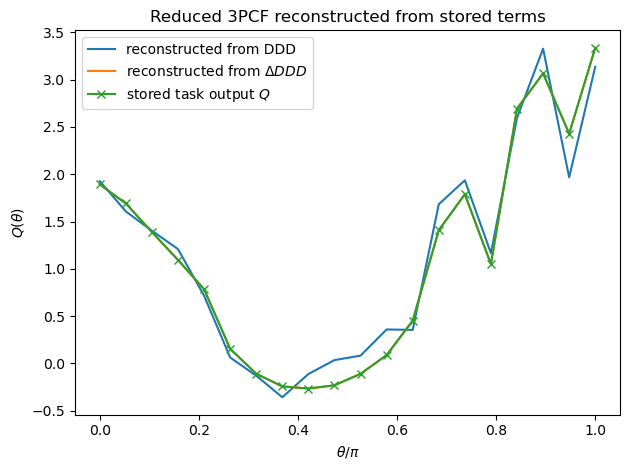

In [8]:
corr3pcf = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl")
Q1 = (corr3pcf.ddd / corr3pcf.rrr - 1 - corr3pcf.xi12 - corr3pcf.xi23 - corr3pcf.xi13)/corr3pcf.zeta_H
Q2 = corr3pcf.delta_ddd / corr3pcf.rrr / corr3pcf.zeta_H

plt.plot(corr3pcf.theta/np.pi, Q1, label='reconstructed from DDD')
plt.plot(corr3pcf.theta/np.pi, Q2, label=r'reconstructed from $\Delta DDD$')
plt.plot(corr3pcf.theta/np.pi, corr3pcf.Q, label='stored task output $Q$', marker="x")
plt.xlabel(r'$\theta/\pi$')
plt.ylabel(r'$Q(\theta)$')
plt.title(r'Reduced 3PCF reconstructed from stored terms')
plt.legend()
plt.tight_layout()
plt.show()


## 2. Convergence and diagnostic plots

These plots focus on how the Monte Carlo and normalization choices affect the result. In particular, `n_rot` controls the number of triangle orientations sampled at each angle, while the later comparisons separate the effects of random handling, center choice, and angular parameterization.


In [9]:
corr3pcf_pcenter_nrot20 = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl")
corr3pcf_pcenter_nrot200 = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot200.pkl")
corr3pcf_pcenter_nrot500 = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot500.pkl")
corr3pcf_pcenter_nrot1000 = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot1000.pkl")
corr3pcf_pcenter_nrot2000 = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot2000.pkl")

corr3pcf_pcenter_nrot1000_mu = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_nrot1000_mu.pkl")
corr3pcf_pcenter_with_random = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_pcenter_with_random.pkl")
corr3pcf_rcenter_nrot200 = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_rcenter_nrot200.pkl")
corr3pcf_rcenter_with_random = Corr3PCFData(data_path="./output/quijote8000_snap004_3pcf_rcenter_with_random.pkl")

18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_pcenter_nrot20.pkl <---
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['ddd', 'rrr', 'd_delta_dd', 'r_delta_dd', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - Reading 3PCF data from ---> ./output/quijote8000_snap004_3pcf_pcenter_nrot200.pkl <---
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - theta: Num = 20, Min = 0, Max = 3.142
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - mu: Num = 20, Min = -1, Max = 1
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - Products loaded: ['rrr', 'd_delta_dd', 'r_delta_dd', 'delta_ddd', 'xi12', 'xi13', 'xi23', 'zeta', 'zeta_H', 'Q']
18:50:24 - INFO - pyhermes.io.base:Corr3PCFData - Read

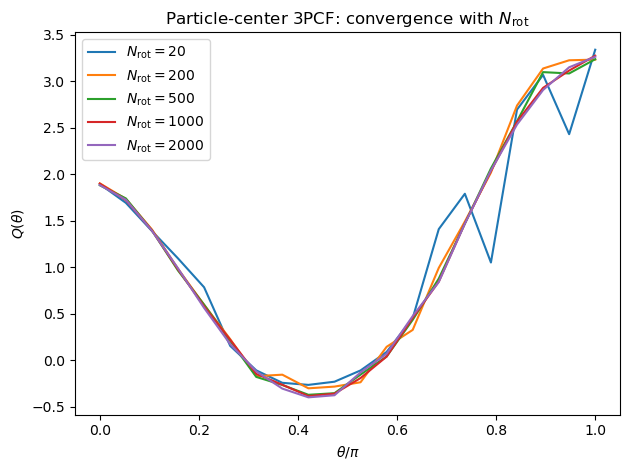

In [10]:
plt.plot(corr3pcf_pcenter_nrot20.theta/np.pi, corr3pcf_pcenter_nrot20.Q, label=r'$N_{\rm rot}=20$')
plt.plot(corr3pcf_pcenter_nrot200.theta/np.pi, corr3pcf_pcenter_nrot200.Q, label=r'$N_{\rm rot}=200$')
plt.plot(corr3pcf_pcenter_nrot500.theta/np.pi, corr3pcf_pcenter_nrot500.Q, label=r'$N_{\rm rot}=500$')
plt.plot(corr3pcf_pcenter_nrot1000.theta/np.pi, corr3pcf_pcenter_nrot1000.Q, label=r'$N_{\rm rot}=1000$')
plt.plot(corr3pcf_pcenter_nrot2000.theta/np.pi, corr3pcf_pcenter_nrot2000.Q, label=r'$N_{\rm rot}=2000$')

plt.legend()
plt.title(r'Particle-center 3PCF: convergence with $N_{\rm rot}$')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.tight_layout()
plt.show()


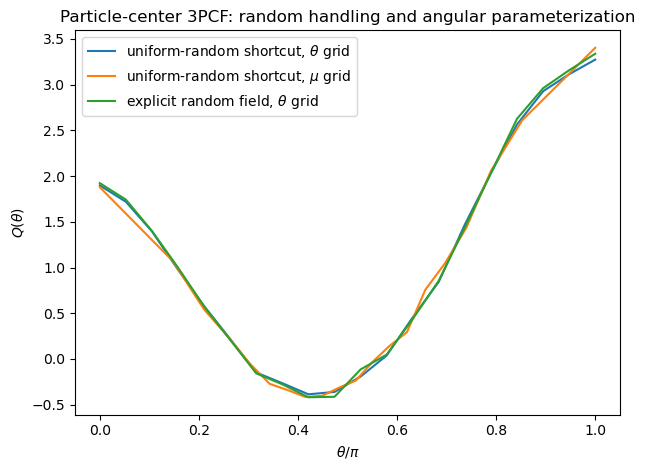

In [11]:
plt.plot(corr3pcf_pcenter_nrot1000.theta/np.pi, corr3pcf_pcenter_nrot1000.Q, label=r'uniform-random shortcut, $\theta$ grid')
plt.plot(corr3pcf_pcenter_nrot1000_mu.theta/np.pi, corr3pcf_pcenter_nrot1000_mu.Q, label=r'uniform-random shortcut, $\mu$ grid')
plt.plot(corr3pcf_pcenter_with_random.theta/np.pi, corr3pcf_pcenter_with_random.Q, label=r'explicit random field, $\theta$ grid')

plt.legend()
plt.title(r'Particle-center 3PCF: random handling and angular parameterization')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.tight_layout()
plt.show()


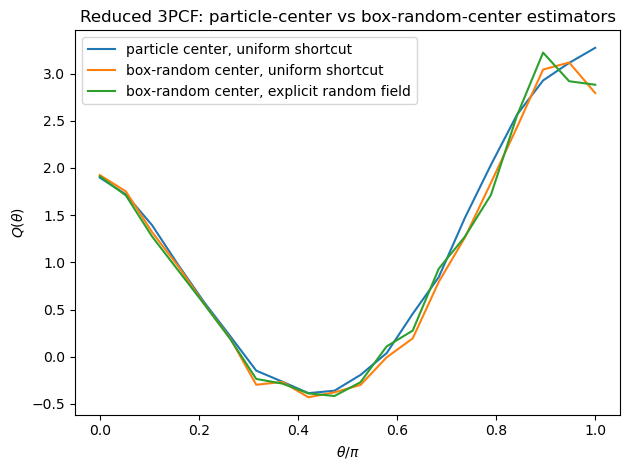

In [12]:
plt.plot(corr3pcf_pcenter_nrot1000.theta/np.pi, corr3pcf_pcenter_nrot1000.Q, label='particle center, uniform shortcut')
plt.plot(corr3pcf_rcenter_nrot200.theta/np.pi, corr3pcf_rcenter_nrot200.Q, label='box-random center, uniform shortcut')
plt.plot(corr3pcf_rcenter_with_random.theta/np.pi, corr3pcf_rcenter_with_random.Q, label='box-random center, explicit random field')

plt.legend()
plt.title(r'Reduced 3PCF: particle-center vs box-random-center estimators')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.tight_layout()
plt.show()


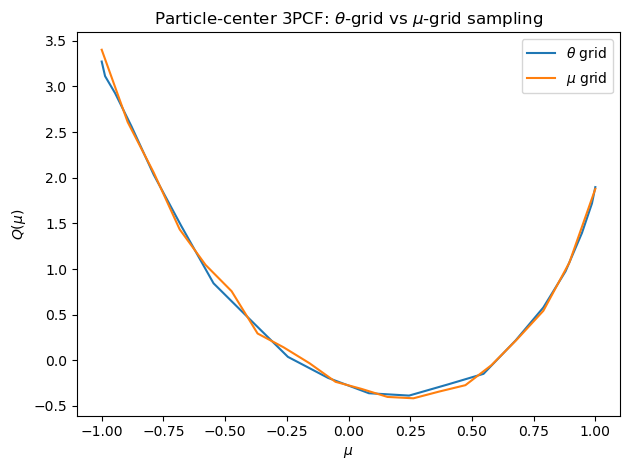

In [13]:
plt.plot(corr3pcf_pcenter_nrot1000.mu, corr3pcf_pcenter_nrot1000.Q, label=r'$\theta$ grid')
plt.plot(corr3pcf_pcenter_nrot1000_mu.mu, corr3pcf_pcenter_nrot1000_mu.Q, label=r'$\mu$ grid')

plt.xlabel(r"$\mu$")
plt.ylabel(r"$Q(\mu)$")
plt.title(r'Particle-center 3PCF: $\theta$-grid vs $\mu$-grid sampling')
plt.legend()
plt.tight_layout()
plt.show() 


## 3. Low-level reconstruction of `Q`

The remaining standard-3PCF cells step outside the task wrapper and work directly with the lower-level kernels. This is where the estimator logic becomes most transparent.


In [14]:
from pyhermes.utils.corr3pcf_kernels import (
    third_side, estimate_triplet_product_particle_centers, estimate_triplet_product_box_random_centers
)
from pyhermes.utils.sampling import random_points_box
from pyhermes.theory.corr2pcf import compute_pair_product_at_sample


### Field definitions and normalizations

The next cell prepares the ingredients used by both low-level estimators.

We work with the following field definitions:

- data field: $D$
- uniform random field: $R$

$$
\rho = \frac{1}{V}, \qquad \langle R \rangle = \rho, \qquad \langle RR \rangle = \rho^2, \qquad \langle RRR \rangle = \rho^3
$$

The three fields entering the triangle statistic are

$$
D_1 = D, \qquad D_2 = D_3 = D @ W_{\rm Sph5}
$$

where $W_{\rm Sph5}$ denotes the spherical smoothing window with radius $5\,{\rm Mpc}/h$.

Their corresponding fluctuation fields are

$$
\Delta D_1 = D_1 - R, \qquad \Delta D_2 = D_2 - R, \qquad \Delta D_3 = D_3 - R
$$

The pair terms used in the hierarchical normalization are

$$
\xi_{12} = \frac{\langle \Delta D_1 \Delta D_2 \rangle}{\langle RR \rangle}, \qquad
\xi_{13} = \frac{\langle \Delta D_1 \Delta D_3 \rangle}{\langle RR \rangle}, \qquad
\xi_{23} = \frac{\langle \Delta D_2 \Delta D_3 \rangle}{\langle RR \rangle}
$$

From these we build

$$
\zeta_{\rm H} = \xi_{12}\xi_{23} + \xi_{13}\xi_{23} + \xi_{12}\xi_{13}, \qquad Q = \zeta / \zeta_{\rm H}
$$

So the low-level task in the following cells is: estimate $\zeta$ with two different center choices, then divide by $\zeta_{\rm H}$ to obtain the reduced 3PCF.


In [15]:
D = ConvolsData(data_path="./output/quijote8000_snap004_sfc.pkl", threads=8)
rho = 1.0 / D.V
R = rho
RR = rho ** 2
RRR = rho ** 3

win_sph5 = WindowFunc({"type": "sphere", "len_args": {"R": 5}}, D.convols_info, threads=8)

D1 = D.copy()
D2 = D @ filter_sph5
D3 = D2.copy()

deltaD1 = D1 - R
deltaD2 = D2 - R
deltaD3 = D3 - R

n_rot = 20
n_theta = 20
theta_values = np.linspace(0.0, np.pi, n_theta)
mu_values = np.cos(theta_values)

r12, r13 = 20.0, 40.0
r23 = third_side(r12, r13, theta_values)

xi12 = compute_pair_product_at_sample({"s": r12}, deltaD1, deltaD2) / RR
xi13 = compute_pair_product_at_sample({"s": r13}, deltaD1, deltaD3) / RR
xi23 = np.array([compute_pair_product_at_sample({"s": r}, deltaD2, deltaD3) / RR for r in r23])
zeta_H = xi12 * xi23 + xi13 * xi23 + xi12 * xi13

18:50:25 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
18:50:25 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1


### Method 1: particle centers

In this estimator, the triangle center is anchored on actual particles. The code below samples rotated triangles around those particle centers and accumulates the corresponding triplet product.

The quantity estimated directly in the code is `d_delta_dd` $= \langle D_1 \, \Delta D_2 \, \Delta D_3 \rangle$

Since $R_1$ is uniform random field, we have `r_delta_dd` $=\langle R_1 \, \Delta D_2 \, \Delta D_3 \rangle=\langle R_1 R_2 R_3 \rangle \times \xi_{23}$

Because the first leg is centered on particles while the other two are fluctuation fields, the reduced three-point term becomes

$$
\zeta = \frac{\langle \Delta D_1 \, \Delta D_2 \, \Delta D_3 \rangle}{\langle R_1 R_2 R_3 \rangle} = \frac{\langle D_1 \, \Delta D_2 \, \Delta D_3 \rangle - \langle R_1 \, \Delta D_2 \, \Delta D_3 \rangle}{\langle R_1 R_2 R_3 \rangle} = 
\frac{\langle D_1 \, \Delta D_2 \, \Delta D_3 \rangle}{\langle R_1 R_2 R_3 \rangle} - \xi_{23}
$$

This is why the code computes `d_delta_dd / RRR - xi23[i]` before dividing by $\zeta_{\rm H}$.


In [16]:
pos1 = D1.get_particle_data()['pos']
pos1_scaled = pos1 * D1.scale_factor
r12_scaled = r12 * D1.scale_factor
r13_scaled = r13 * D1.scale_factor
weight1 = np.ones(pos1_scaled.shape[0])
weight1_sum = weight1.sum()

In [17]:
zeta = np.empty_like(theta_values, dtype=np.float64)

for i, mu in enumerate(mu_values):
    d_delta_dd = estimate_triplet_product_particle_centers(
        r12_scaled, r13_scaled, mu, 
        pos1_scaled, weight1, weight1_sum, n_rot, 
        R, deltaD2.epsilon, deltaD3.epsilon, 
        D1.phi_array, D1.L, D1.phi_resolution, D1.phi_support,
        seed_base_rot=43, mu_index=i
        )
    zeta[i] = d_delta_dd / RRR - xi23[i]

Q_pcenter = zeta / zeta_H

### Method 2: random box centers

In this estimator, the triangle center is drawn uniformly from the box. The code below measures the triplet product of the fluctuation fields directly, which makes the random subtraction explicit inside the estimator.

The directly estimated quantity is `delta_ddd` $= \langle \Delta D_1 \, \Delta D_2 \, \Delta D_3 \rangle$

so the corresponding three-point term is simply

$$
\zeta = \frac{\langle \Delta D_1 \, \Delta D_2 \, \Delta D_3 \rangle}{\langle R_1 R_2 R_3 \rangle}
$$

This is the form typically used in the random-center pipeline above.


In [18]:
rand1_scaled = random_points_box(count=1_000_000, box_size=D.L, seed=1000045)
r12_scaled = r12 * D1.scale_factor
r13_scaled = r13 * D1.scale_factor

In [19]:
zeta = np.empty_like(theta_values, dtype=np.float64)
for i, mu in enumerate(mu_values):
    delta_ddd = estimate_triplet_product_box_random_centers(
        r12_scaled, r13_scaled, mu, 
        rand1_scaled, n_rot,
        deltaD1.epsilon, deltaD2.epsilon, deltaD3.epsilon,
        D1.phi_array, D1.L, D1.phi_resolution, D1.phi_support,
        seed_base_rot=43, mu_index=i
    )
    zeta[i] = delta_ddd / RRR

zeta_H = xi12 * xi23 + xi13 * xi23 + xi12 * xi13
Q_rcenter = zeta / zeta_H

### Compare high-level and low-level estimators

This plot places the notebook-level reconstruction next to the command-line result so that the agreement between the two implementations is easy to inspect.


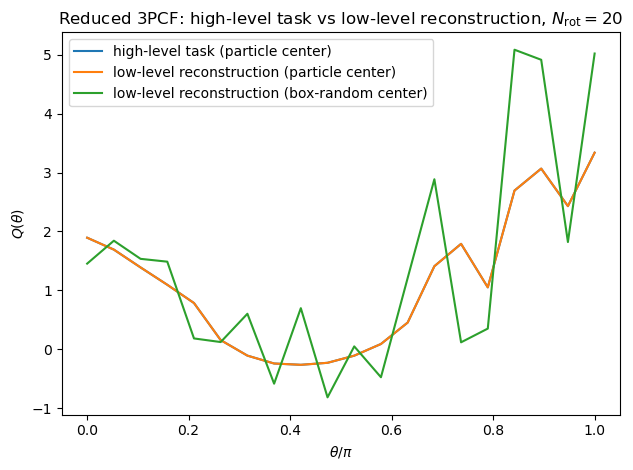

In [20]:
plt.plot(corr3pcf_pcenter_nrot20.theta/np.pi, corr3pcf_pcenter_nrot20.Q, label='high-level task (particle center)')
plt.plot(theta_values/np.pi, Q_pcenter, label='low-level reconstruction (particle center)')
plt.plot(theta_values/np.pi, Q_rcenter, label='low-level reconstruction (box-random center)')

plt.legend()
plt.title(r'Reduced 3PCF: high-level task vs low-level reconstruction, $N_{\rm rot}=20$')
plt.xlabel(r"$\theta/\pi$")
plt.ylabel(r"$Q(\theta)$")
plt.tight_layout()
plt.show()


## 4. Advanced topic: 3PCF multipoles

The final section switches from direct angular curves to a multipole representation. The cells below do not rerun the estimator from scratch; instead, they load saved multipole outputs and compare how the result changes with the truncation order `l_max` and the field resolution parameter `J`.


In [21]:
corr3pcf_mul_j8_lmax7 = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_lmax7_full.pkl")
corr3pcf_mul_j8_lmax10 = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_lmax10_full.pkl")
corr3pcf_mul_j8_lmax14 = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_lmax14_full.pkl")
corr3pcf_mul_j8_lmax20 = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_lmax20.pkl")
corr3pcf_mul_j9_lmax7 = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_J9_lmax7.pkl")
corr3pcf_mul_j9_lmax14 = Corr3PCFMultipoleData(data_path="./output/quijote8000_snap004_3pcf_multipole_J9_lmax14.pkl")

18:51:35 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Reading 3PCF Multipole data from ---> ./output/quijote8000_snap004_3pcf_multipole_lmax7_full.pkl <---
18:51:35 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - l: Num = 8, Min = 0, Max = 7
18:51:35 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Products loaded: ['ddd_l', 'rrr_l', 'delta_ddd_l', 'zeta_l']
18:51:35 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Reading 3PCF Multipole data from ---> ./output/quijote8000_snap004_3pcf_multipole_lmax10_full.pkl <---
18:51:35 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - l: Num = 11, Min = 0, Max = 10
18:51:35 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Products loaded: ['ddd_l', 'rrr_l', 'delta_ddd_l', 'zeta_l']
18:51:35 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - Reading 3PCF Multipole data from ---> ./output/quijote8000_snap004_3pcf_multipole_lmax14_full.pkl <---
18:51:35 - INFO - pyhermes.io.base:Corr3PCFMultipoleData - l: Num = 15, Min = 0, Max = 14
18:51:3

### Compare multipole spectra at different truncation orders `lmax`

The next plot keeps the field resolution fixed at `J=8` and varies only `lmax`, so it isolates how aggressively truncating the angular expansion changes the recovered multipole spectrum.


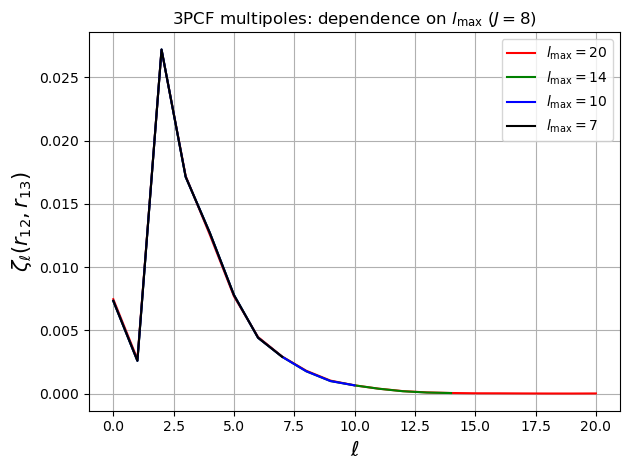

In [22]:
plt.plot(corr3pcf_mul_j8_lmax20.l, corr3pcf_mul_j8_lmax20.zeta_l, label=r'$l_{\max}=20$', color='r')
plt.plot(corr3pcf_mul_j8_lmax14.l, corr3pcf_mul_j8_lmax14.zeta_l, label=r'$l_{\max}=14$', color='g')
plt.plot(corr3pcf_mul_j8_lmax10.l, corr3pcf_mul_j8_lmax10.zeta_l, label=r'$l_{\max}=10$', color='b')
plt.plot(corr3pcf_mul_j8_lmax7.l, corr3pcf_mul_j8_lmax7.zeta_l, label=r'$l_{\max}=7$', color='k')

plt.legend()
plt.title(r'3PCF multipoles: dependence on $l_{\max}$ ($J=8$)')
plt.xlabel(r'$\ell$', fontsize=15)
plt.ylabel(r'$\zeta_\ell(r_{12}, r_{13})$', fontsize=15)
plt.grid()
plt.tight_layout()
plt.show()


### Compare field resolution `J` at fixed `lmax=14`

After varying `lmax` at fixed `J=8`, the next plot holds `lmax=14` fixed and changes only the field resolution. This isolates how the multiresolution representation itself affects the recovered multipole spectrum.


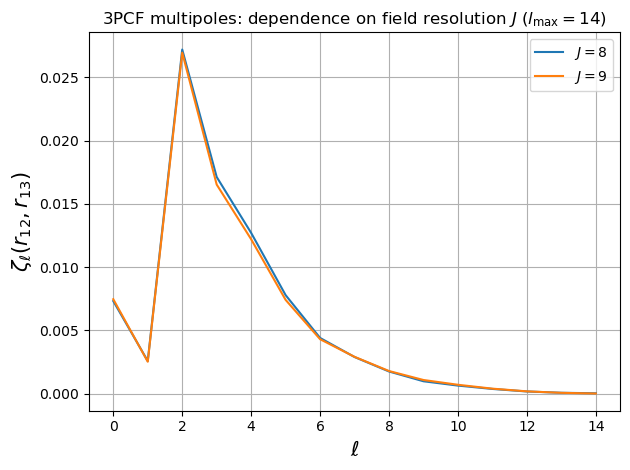

In [23]:
plt.plot(corr3pcf_mul_j8_lmax14.l, corr3pcf_mul_j8_lmax14.zeta_l, label=r'$J=8$')
plt.plot(corr3pcf_mul_j9_lmax14.l, corr3pcf_mul_j9_lmax14.zeta_l, label=r'$J=9$')

plt.title(r'3PCF multipoles: dependence on field resolution $J$ ($l_{\max}=14$)')
plt.xlabel(r'$\ell$', fontsize=15)
plt.ylabel(r'$\zeta_{\ell}(r_{12}, r_{13})$', fontsize=15)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()


### Inspect normalized raw multipole components

The final plot in this notebook breaks the multipole output into its raw building blocks, all normalized by `rho^3`, so it is easier to compare the relative scale of `RRR`, `DDD`, and `$(\Delta D)^3$`-type terms.


In [24]:
D = ConvolsData(data_path='./output/quijote8000_snap004_sfc.pkl')
rho = 1 / D.V
l = corr3pcf_mul_j8_lmax14.l
rrr_l = corr3pcf_mul_j8_lmax14.rrr_l
ddd_l = corr3pcf_mul_j8_lmax14.ddd_l
delta_ddd_l = corr3pcf_mul_j8_lmax14.delta_ddd_l

18:51:35 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
18:51:35 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1


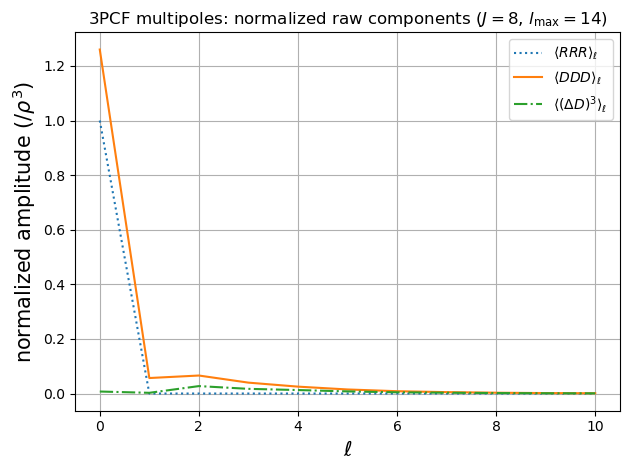

In [25]:
lmin, lmax = 0, 10
plt.plot(l[lmin:lmax+1], rrr_l[lmin:lmax+1]/rho**3, label=r'$\langle RRR \rangle_\ell$', ls=":")
plt.plot(l[lmin:lmax+1], ddd_l[lmin:lmax+1]/rho**3, label=r'$\langle DDD \rangle_\ell$', ls="-")
plt.plot(l[lmin:lmax+1], delta_ddd_l[lmin:lmax+1]/rho**3, label=r'$\langle (\Delta D)^3 \rangle_\ell$', ls="-.")

plt.title(r'3PCF multipoles: normalized raw components ($J=8$, $l_{\max}=14$)')
plt.xlabel(r'$\ell$', fontsize=15)
plt.ylabel(r'normalized amplitude $(/\rho^3)$', fontsize=15)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()
